In [33]:
import torch
from torch import nn, cuda, optim, inference_mode
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [34]:
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [35]:
len(X), len(y)

(1000, 1000)

In [36]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [37]:
circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


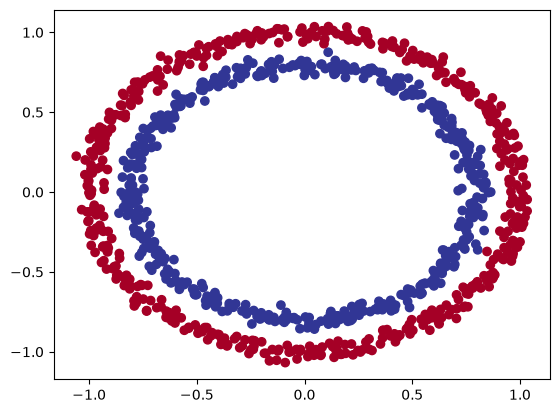

In [38]:
plt.scatter(circles['X1'], circles['X2'], c=y, cmap=plt.cm.RdYlBu);

In [39]:
X.shape, y.shape

((1000, 2), (1000,))

In [40]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

Turn data into tensors

In [41]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [45]:
X_train.shape, y_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [46]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
        # self.two_layer = nn.Sequential(
        #     nn.Linear(2, 5),
        #     nn.Linear(5, 1)
        # )

    def forward(self, x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        return x
        # same as return self.layer_2(self.layer_1(x))
        # return self.two_layer(x)

In [47]:
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [48]:
next(model_0.parameters()).device

device(type='cuda', index=0)

### `nn.Sequntial()`

In [49]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [50]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [51]:
with torch.inference_mode():
    untrained_pred = model_0(X_test.to(device))

print(f"Len of pred: {len(untrained_pred)}, Shape:{untrained_pred.shape}")
print(f"Len of test sample: {len(X_test)}, Shape:{X_test.shape}")
print(f"First 10 pred: {untrained_pred[:10]}")
print(f"First 10 label: {y_test[:10]}")

Len of pred: 200, Shape:torch.Size([200, 1])
Len of test sample: 200, Shape:torch.Size([200, 2])
First 10 pred: tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')
First 10 label: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [52]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.03)

In [53]:
# Calculate Accuracy - Important for classification problems
def accuracy_fn(y_true, y_pred):
    correct = sum(y_true == y_pred)
    acc = (correct / len(y_true)) * 100
    return acc

In [54]:
# View first five outputs of forward pass on test data (raw outputs = logits)
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))
y_logits[:5]

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [55]:
# turn the raw output into probability using sigmoid (Binary class)
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob[:5]

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [56]:
torch.round(y_pred_prob[:5])

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

We use `torch.round()` to make a desision through a decision boundary (threshold)

usually:
* `y_pred_prob` >= 0.5; `y` = 1
* `y_pred_prob` < 0.5; `y` = 0

In [57]:
# Checking

y_preds = torch.round(y_pred_prob)[:5]
y_pred_label = torch.round(torch.sigmoid(model_0(X_test.to(device))))[:5]

print(torch.eq(y_pred_label.squeeze(), y_preds.squeeze()))

tensor([True, True, True, True, True], device='cuda:0')


### Building Training and Testing loop

In [58]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put the data into same device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    # train_loss = loss_fn(torch.sigmoid(y_logits), y_train)  # nn.BCELoss expects probabilities as input
    train_loss = loss_fn(y_logits, y_train)  # nn.BCEWithLogitsLoss expects raw logits of our model as input

    acc = accuracy_fn(y_train, y_preds)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_y_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_y_pred)

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.69796 | Accuracy: 51.88% | Test loss: 0.69455 | Test accuracy: 58.00%
Epoch: 10 | Train Loss: 0.69717 | Accuracy: 52.00% | Test loss: 0.69397 | Test accuracy: 56.50%
Epoch: 20 | Train Loss: 0.69655 | Accuracy: 51.25% | Test loss: 0.69354 | Test accuracy: 56.00%
Epoch: 30 | Train Loss: 0.69606 | Accuracy: 51.38% | Test loss: 0.69321 | Test accuracy: 55.00%
Epoch: 40 | Train Loss: 0.69566 | Accuracy: 51.12% | Test loss: 0.69297 | Test accuracy: 52.00%
Epoch: 50 | Train Loss: 0.69534 | Accuracy: 51.62% | Test loss: 0.69279 | Test accuracy: 51.50%
Epoch: 60 | Train Loss: 0.69507 | Accuracy: 51.62% | Test loss: 0.69265 | Test accuracy: 51.50%
Epoch: 70 | Train Loss: 0.69485 | Accuracy: 51.75% | Test loss: 0.69254 | Test accuracy: 50.00%
Epoch: 80 | Train Loss: 0.69466 | Accuracy: 52.00% | Test loss: 0.69247 | Test accuracy: 49.50%
Epoch: 90 | Train Loss: 0.69450 | Accuracy: 51.12% | Test loss: 0.69241 | Test accuracy: 49.50%
Epoch: 100 | Train Loss: 0.69436 | Accura

### Using a `plot_decision_boundary()` from github

In [59]:
import requests
from pathlib import Path

# Download helper function from Learn PyTorch GitHub repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping downloading")
else:
    print("Downloading helper_functions.py")
    request = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py"
    )
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_functions.py already exists, skipping downloading


In [63]:
X_train.shape, y_train.shape

(torch.Size([800, 2]), torch.Size([800]))

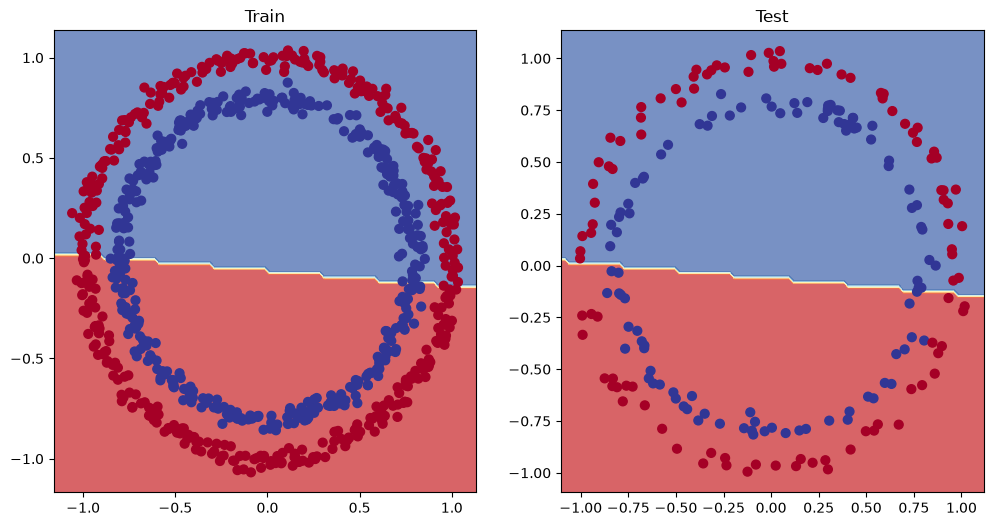

In [60]:
from helper_functions import plot_predictions, plot_decision_boundary

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)